In [2]:
%load_ext autoreload
%autoreload 2

# Consts and imports

In [3]:
DATA_FOLDER = "/home/einsunza/Desktop/work/code/data/dam_simulator/"
CONSOLIDATED_DATA_FOLDER = DATA_FOLDER + "consolidated/"
CONSOLIDATED_PRICE_FRANCE_FILE = CONSOLIDATED_DATA_FOLDER + "price_france.parquet"
CONSOLIDATED_UOF_ZONES_FILE = CONSOLIDATED_DATA_FOLDER + "uof_zones.parquet"
MARGINALPDBC_CONSOLIDATED_PATH = (
    "/home/einsunza/Desktop/work/code/data/dayahead/consolidated/marginalpdbc.parquet"
)
PCA_START_DATE = "2024-01-01"
START_ANALYSIS = "2025-07-01"
END_ANALYSIS = "2025-07-08"

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

# Add the src directory to sys.path
sys.path.append("/home/einsunza/Desktop/work/mibel-simulator/src")
sys.path.append("/home/einsunza/Desktop/work/code")

import mibel_simulator.columns as cols
from mibel_simulator.residual_demand_curve import (
    calculate_residual_demand_curves,
    create_homothetic_sell_profiles,
)

/home/einsunza/anaconda3/envs/pyomo_class/lib/python3.13/site-packages/pandera/_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


# Cargar datos

In [4]:
I3DIA01 = pd.read_parquet(
    "/home/einsunza/Desktop/work/code/data/I3DIA_consolidated/consolidated_I3DIA01.parquet"
)
marginalpdbc_raw = pd.read_parquet(
    MARGINALPDBC_CONSOLIDATED_PATH,
    # filters=[["dat_sesion", "==", pd.to_datetime(STUDIED_DATE)]],
    # engine="pyarrow",
)

price_france = pd.read_parquet(CONSOLIDATED_PRICE_FRANCE_FILE)

uof_zones = pd.read_parquet(CONSOLIDATED_UOF_ZONES_FILE)
uof_zones = pd.concat(
    [
        uof_zones,
        pd.DataFrame(
            {
                cols.ID_UNIDAD: ["SMBV02"],
                cols.CAT_PAIS: ["PT"],
            }
        ),
    ],
    ignore_index=True,
)

# Generar perfil oferta

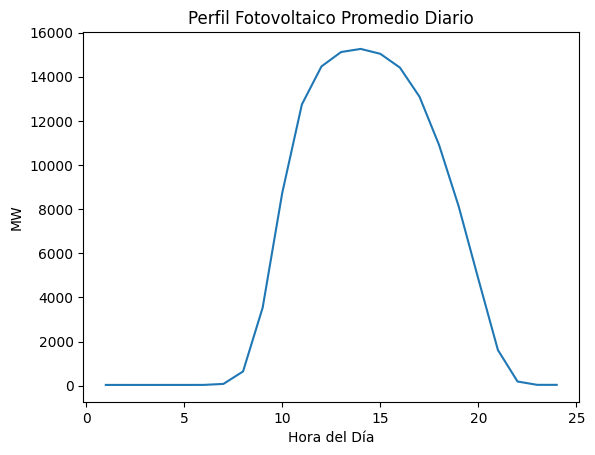

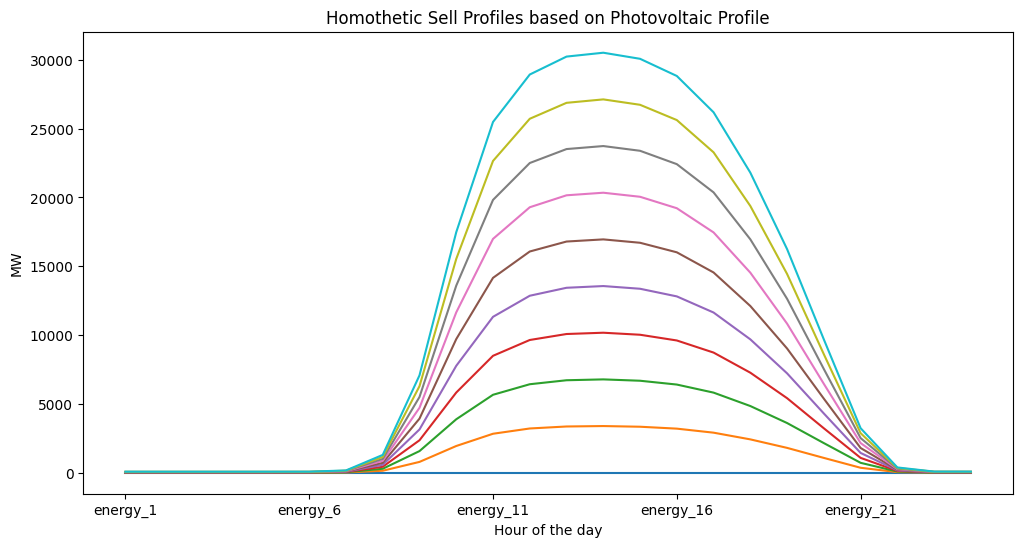

In [5]:
I3DIA01_solar = I3DIA01.query('Concepto == "Solar fotovoltaica"')

perfil_fotovoltaico = {}

for i in range(1, 25):
    qhs = [str((i - 1) * 4 + j) for j in range(1, 5)]
    perfil_fotovoltaico[i] = I3DIA01_solar[qhs].sum(axis=1).mean()

perfil_fotovoltaico_series = pd.Series(perfil_fotovoltaico)
perfil_fotovoltaico_series.plot(
    title="Perfil Fotovoltaico Promedio Diario",
    ylabel="MW",
    xlabel="Hora del Día",
)
plt.show()

scaling_factors = np.linspace(0, 2, num=10)
sell_profiles = create_homothetic_sell_profiles(
    perfil_fotovoltaico_series, scaling_factors
)
sell_profiles.T.plot(
    title="Homothetic Sell Profiles based on Photovoltaic Profile",
    ylabel="MW",
    xlabel="Hour of the day",
    figsize=(12, 6),
    legend=False,
)
plt.show()

# Calculate RDCs using sell profiles

In [6]:
TRIALS_COUNT = 100

In [7]:
# for date in pd.date_range(start=START_ANALYSIS, end=END_ANALYSIS):
#     DATE_STUDIED = date.strftime("%Y-%m-%d")
#     print("DATE_STUDIED: ", DATE_STUDIED)

#     price_france_date = price_france[price_france[cols.DATE_SESION] == DATE_STUDIED]

#     det_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/det/DET_{DATE_STUDIED.replace('-', '')}.1"
#     cab_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/cab/CAB_{DATE_STUDIED.replace('-', '')}.1"
#     capacidad_inter_pbc_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/capacidad_inter_pbc/capacidad_inter_pbc_{DATE_STUDIED.replace('-', '')}.1"

#     residual_demand_curve = calculate_residual_demand_curves(
#         sell_profiles,
#         det_file,
#         cab_file,
#         capacidad_inter_pbc_file,
#         price_france_date,
#         uof_zones,
#         sell_country="ES",
#         trials_count=TRIALS_COUNT,
#         zones_default_to_spain=True,
#         n_jobs=14,
#     )

#     residual_demand_curve.attrs["date_studied"] = DATE_STUDIED
#     residual_demand_curve.attrs["trials_count"] = TRIALS_COUNT
#     residual_demand_curve.to_parquet(
#         f"results/residual_demand_curve_PV_{DATE_STUDIED}.parquet"
#     )

## Calculate profile prices using pca component

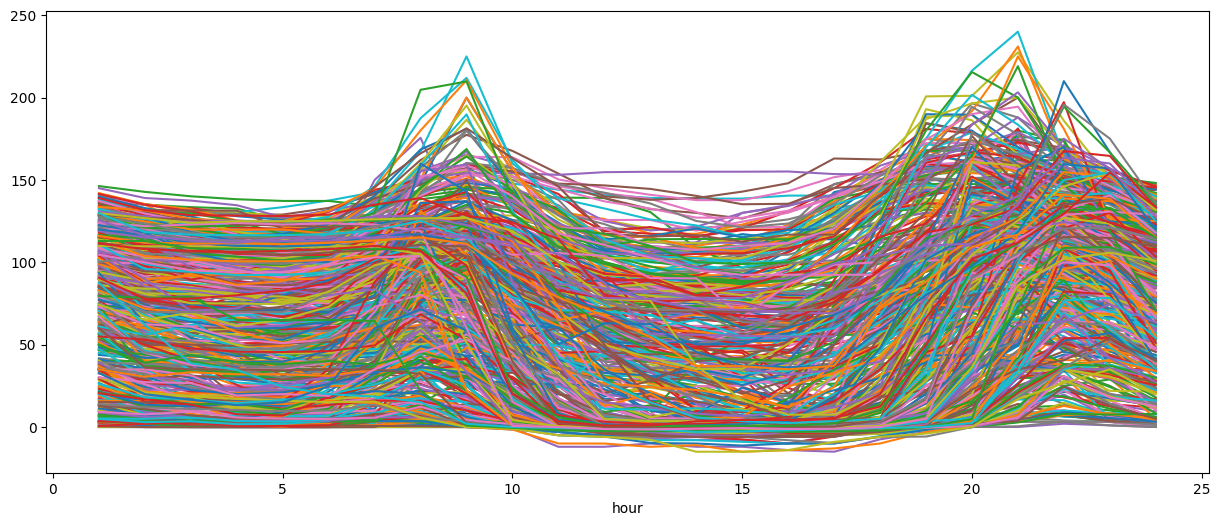

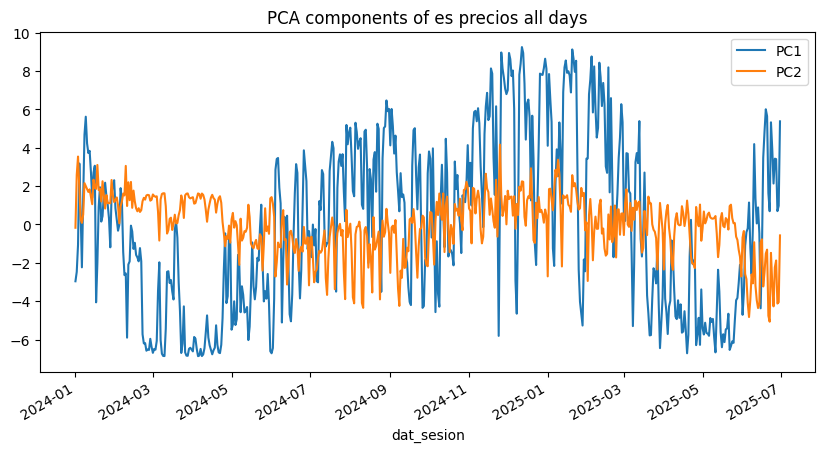

PCA explained variance ratio:


array([0.81426895, 0.09938553])

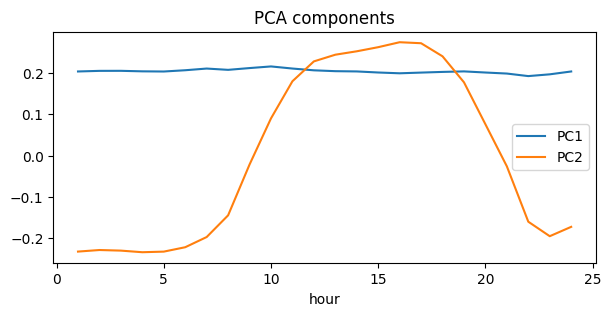

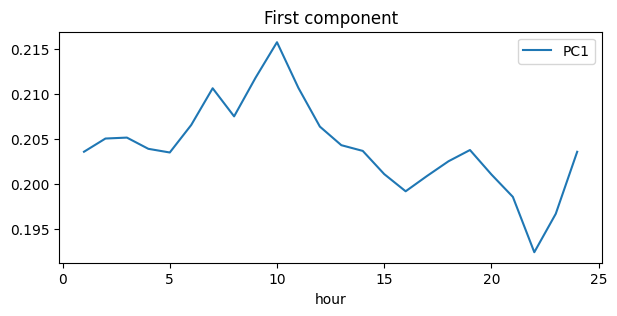

In [8]:
from matplotlib import pyplot as plt


marginalpdbc_es = (
    marginalpdbc_raw.query(
        "@PCA_START_DATE <= dat_sesion < @START_ANALYSIS and hour <= 24"
    )
    .pivot(
        index="dat_sesion",
        columns="hour",
        values="precio_es",
    )
    .dropna()
)
marginalpdbc_es.T.plot(figsize=(15, 6), legend=False)
plt.show()

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler

preprocessor = StandardScaler()
X = preprocessor.fit_transform(marginalpdbc_es)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca_es = pca.fit_transform(X)
X_pca_es_df = pd.DataFrame(
    X_pca_es,
    index=marginalpdbc_es.index,
    columns=[f"PC{i+1}" for i in range(X_pca_es.shape[1])],
)
X_pca_es_df.plot(
    figsize=(10, 5), legend=True, title="PCA components of es precios all days"
)
plt.show()
print("PCA explained variance ratio:")
display(pca.explained_variance_ratio_)  # second 3 components explain 90% of variance
# display(pca.explained_variance_ratio_.cumsum().tolist())

pca_components_es_df = pd.DataFrame(
    pca.components_.T,
    index=marginalpdbc_es.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
)

pca_components_es_df.plot(figsize=(7, 3), legend=True, title="PCA components")
plt.show()

first_component = pca_components_es_df.iloc[:, 0]
first_component.plot(figsize=(7, 3), legend=True, title="First component")
plt.show()

In [9]:
def get_price_curves(studied_date):
    spain_cleared_prices_date = marginalpdbc_raw.query(
        f'dat_sesion == "{studied_date}"'
    ).set_index("hour", verify_integrity=True)["precio_es"]

    spain_cleared_prices_date_np = spain_cleared_prices_date.to_numpy()
    # spain_cleared_prices_date.plot(
    #     title=f"Spain Cleared Prices on {studied_date}",
    #     ylabel="€/MWh",
    #     xlabel="Hour of the day",
    # )
    spain_cleared_prices_date_scaled = preprocessor.transform(
        spain_cleared_prices_date_np.reshape(1, -1)
    )
    spain_cleared_prices_date_scaled = spain_cleared_prices_date_scaled.flatten()

    multipliers = np.arange(-20, 20, 0.5)

    price_curves_scaled = [
        spain_cleared_prices_date_scaled + m * first_component for m in multipliers
    ]
    price_curves = preprocessor.inverse_transform(price_curves_scaled)
    return price_curves

/tmp/ipykernel_762922/1711850340.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  spain_cleared_prices_date = marginalpdbc_raw.query(


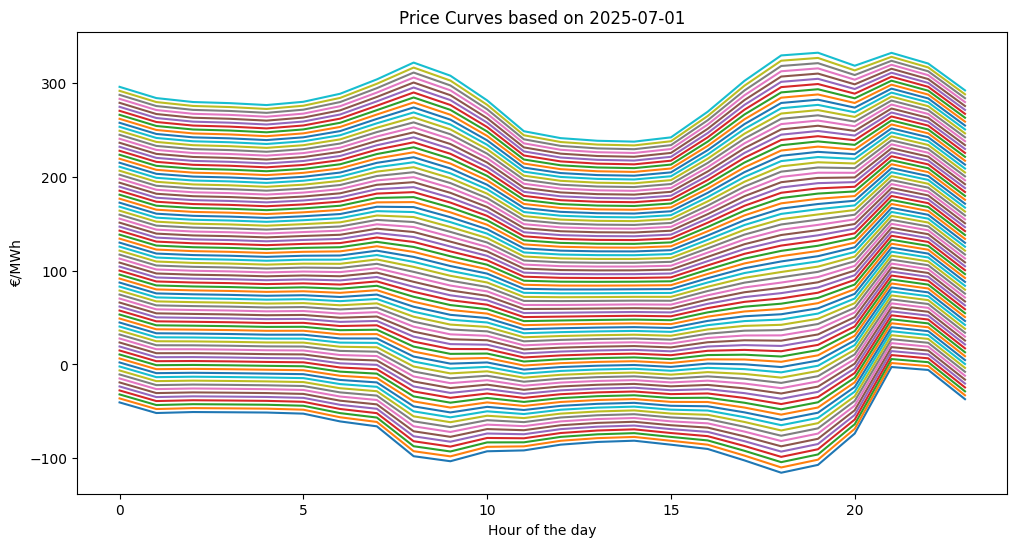

In [10]:
price_array = get_price_curves("2025-07-01")
fig, ax = plt.subplots(figsize=(12, 6))
plt.plot(price_array.T)
plt.title("Price Curves based on 2025-07-01")
plt.xlabel("Hour of the day")
plt.ylabel("€/MWh")
plt.show()

# Calculate analytic RDCs

/tmp/ipykernel_762922/1711850340.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  spain_cleared_prices_date = marginalpdbc_raw.query(


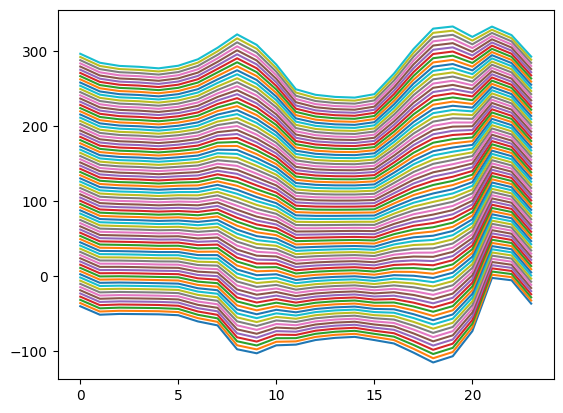

Period 25 represents less than 1% of the data, dropping it. File: /home/einsunza/Desktop/work/code/data/dam_simulator/det/DET_20250701.1
The following id_unidad in det_cab_date were not found in unidades_zona and have been assigned to ES: ['NXVD253' 'PISUC01']
Period 25 represents less than 1% of the data, dropping it. File: /home/einsunza/Desktop/work/code/data/dam_simulator/det/DET_20250701.1


{'residual_demands_with_simple_bids_curves':        price_1     price_2     price_3     price_4     price_5     price_6  \
 0   -40.554190  -51.876913  -50.826125  -51.070288  -51.360796  -52.544811   
 1   -36.290835  -47.621990  -46.637972  -46.894031  -47.206776  -48.331690   
 2   -32.027481  -43.367067  -42.449819  -42.717774  -43.052757  -44.118570   
 3   -27.764126  -39.112144  -38.261666  -38.541517  -38.898737  -39.905450   
 4   -23.500771  -34.857221  -34.073513  -34.365259  -34.744717  -35.692330   
 ..         ...         ...         ...         ...         ...         ...   
 75  279.197416  267.242299  263.285360  262.149002  260.190697  263.439209   
 76  283.460771  271.497221  267.473513  266.325259  264.344717  267.652330   
 77  287.724126  275.752144  271.661666  270.501517  268.498737  271.865450   
 78  291.987481  280.007067  275.849819  274.677774  272.652757  276.078570   
 79  296.250835  284.261990  280.037972  278.854031  276.806776  280.291690   
 
      

In [ ]:
from mibel_simulator.calculate_residual_demand_with_price_curves import (
    calculate_residual_demand_with_price_curves,
)
from mibel_simulator.data_preprocessor import get_det_cab_date_for_simulation
from mibel_simulator.parse_omie_files import (
    parse_cab_file,
    parse_capacidad_inter_file,
    parse_det_file,
)


date_plotted = START_ANALYSIS
price_curves_date = get_price_curves(date_plotted)
price_curves_date

plt.plot(price_curves_date.T)
plt.show()

price_france_date = price_france[price_france[cols.DATE_SESION] == date_plotted]


det_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/det/DET_{date_plotted.replace('-', '')}.1"
cab_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/cab/CAB_{date_plotted.replace('-', '')}.1"
capacidad_inter_pbc_file = f"/home/einsunza/Desktop/work/code/data/dam_simulator/capacidad_inter_pbc/capacidad_inter_pbc_{date_plotted.replace('-', '')}.1"

det_date = parse_det_file(det_file)
cab_date = parse_cab_file(cab_file)
capacidad_inter_date = parse_capacidad_inter_file(capacidad_inter_pbc_file)
det_cab_date = get_det_cab_date_for_simulation(
    det_date, cab_date, uof_zones, zones_default_to_spain=True
)

residual_demand_curves_dict = calculate_residual_demand_with_price_curves(
    price_curves_date,
    det_file,
    cab_file,
    capacidad_inter_pbc_file,
    uof_zones,
    zones_default_to_spain=True,
)
residual_demand_curves_dict

# Plot all RDCs

In [19]:
PV_residual_demand_curve = pd.read_parquet(
    f"results/residual_demand_curve_PV_{START_ANALYSIS}.parquet"
)
PV_residual_demand_curve

,price_1,price_2,price_3,price_4,price_5,price_6,price_7,price_8,price_9,price_10,...,energy_15,energy_16,energy_17,energy_18,energy_19,energy_20,energy_21,energy_22,energy_23,energy_24
scale_0.00,129.98,118.32,116.70,115.98,114.80,115.98,116.22,121.40,114.74,105.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
scale_0.22,129.98,118.32,116.70,115.98,114.80,115.98,116.22,121.31,114.74,93.19,...,3342.081635,3203.402493,2910.296637,2422.926498,1805.336027,1076.213002,359.571862,42.607354,9.131350,8.959513
scale_0.44,133.38,120.80,117.82,116.38,115.98,116.38,116.70,124.80,114.74,93.19,...,6684.163270,6406.804987,5820.593273,4845.852995,3610.672055,2152.426004,719.143725,85.214709,18.262701,17.919026
scale_0.67,139.92,122.80,119.54,116.63,116.33,116.46,117.82,125.50,114.74,80.11,...,10026.244905,9610.207480,8730.889910,7268.779493,5416.008082,3228.639006,1078.715587,127.822063,27.394051,26.878539
scale_0.89,139.52,122.80,119.54,116.63,116.33,116.46,117.82,125.00,114.00,45.10,...,13368.326539,12813.609973,11641.186546,9691.705991,7221.344110,4304.852008,1438.287450,170.429418,36.525402,35.838052
scale_1.11,140.95,125.00,120.10,117.09,116.43,116.84,118.94,126.76,111.85,-0.00,...,16710.408174,16017.012467,14551.483183,12114.632488,9026.680137,5381.065010,1797.859312,213.036772,45.656752,44.797565
scale_1.33,145.01,130.13,122.30,117.96,116.73,117.96,120.71,130.07,111.70,-0.00,...,20052.489809,19220.414960,17461.779819,14537.558986,10832.016165,6457.278012,2157.431175,255.644127,54.788102,53.757078
scale_1.56,145.01,130.13,122.30,117.96,116.70,117.96,120.71,129.00,110.00,-0.60,...,23394.571444,22423.817453,20372.076456,16960.485484,12637.352192,7533.491014,2517.003037,298.251481,63.919453,62.716591
scale_1.78,145.01,130.13,122.30,117.96,116.70,117.96,120.71,126.40,109.00,-2.10,...,26736.653079,25627.219946,23282.373092,19383.411981,14442.688220,8609.704016,2876.574900,340.858835,73.050803,71.676104
scale_2.00,145.01,130.13,122.30,117.96,116.70,117.96,120.71,125.00,108.00,-6.00,...,30078.734714,28830.622440,26192.669729,21806.338479,16248.024247,9685.917018,3236.146762,383.466190,82.182154,80.635617


In [18]:
residual_demand_curves_dict["residual_demands_with_saturation_curves"]

,price_1,price_2,price_3,price_4,price_5,price_6,price_7,price_8,price_9,price_10,...,energy_15,energy_16,energy_17,energy_18,energy_19,energy_20,energy_21,energy_22,energy_23,energy_24
0,-40.554190,-51.876913,-50.826125,-51.070288,-51.360796,-52.544811,-60.841228,-66.095153,-97.970632,-103.344945,...,33782.2,33047.0,32875.1,33198.4,32500.5,32621.3,30892.7,24758.4,25130.6,27663.2
1,-36.290835,-47.621990,-46.637972,-46.894031,-47.206776,-48.331690,-56.414697,-61.407774,-92.652866,-98.136322,...,33780.1,33047.0,32875.1,32648.3,32500.5,32621.3,30892.7,21482.0,24382.0,27641.3
2,-32.027481,-43.367067,-42.449819,-42.717774,-43.052757,-44.118570,-51.988167,-56.720395,-87.335101,-92.927698,...,33780.1,33045.0,32875.1,32616.6,32500.5,32285.0,30888.1,21153.2,21255.0,27283.6
3,-27.764126,-39.112144,-38.261666,-38.541517,-38.898737,-39.905450,-47.561636,-52.033017,-82.017335,-87.719074,...,33780.1,33045.0,32873.3,32616.6,32033.8,32276.5,30867.8,21006.1,20926.8,27074.9
4,-23.500771,-34.857221,-34.073513,-34.365259,-34.744717,-35.692330,-43.135105,-47.345638,-76.699569,-82.510451,...,33774.1,33045.0,32873.3,32616.6,32014.3,32276.5,30867.8,20987.8,20830.4,26753.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,279.197416,267.242299,263.285360,262.149002,260.190697,263.439209,271.148575,285.458259,300.861803,287.301827,...,-22922.1,-23870.9,-25628.0,-31717.9,-34982.8,-33104.2,-24477.3,-25881.9,-24481.7,-16935.9
76,283.460771,271.497221,267.473513,266.325259,264.344717,267.652330,275.575105,290.145638,306.179569,292.510451,...,-23252.8,-23871.6,-25632.3,-31717.9,-34982.8,-33283.1,-28492.7,-25926.9,-25417.4,-16950.5
77,287.724126,275.752144,271.661666,270.501517,268.498737,271.865450,280.001636,294.833017,311.497335,297.719074,...,-23253.6,-23924.0,-25679.8,-31717.9,-34982.8,-33330.4,-29536.4,-26326.9,-25417.4,-22002.5
78,291.987481,280.007067,275.849819,274.677774,272.652757,276.078570,284.428167,299.520395,316.815101,302.927698,...,-23309.2,-24974.4,-25679.8,-31910.2,-35031.3,-33330.4,-29536.4,-26326.9,-25417.4,-22005.5


In [ ]:
from importlib import reload
import mibel_simulator.plot_helpers as my_module

reload(my_module)
from mibel_simulator.plot_helpers import plot_residual_demand_curves

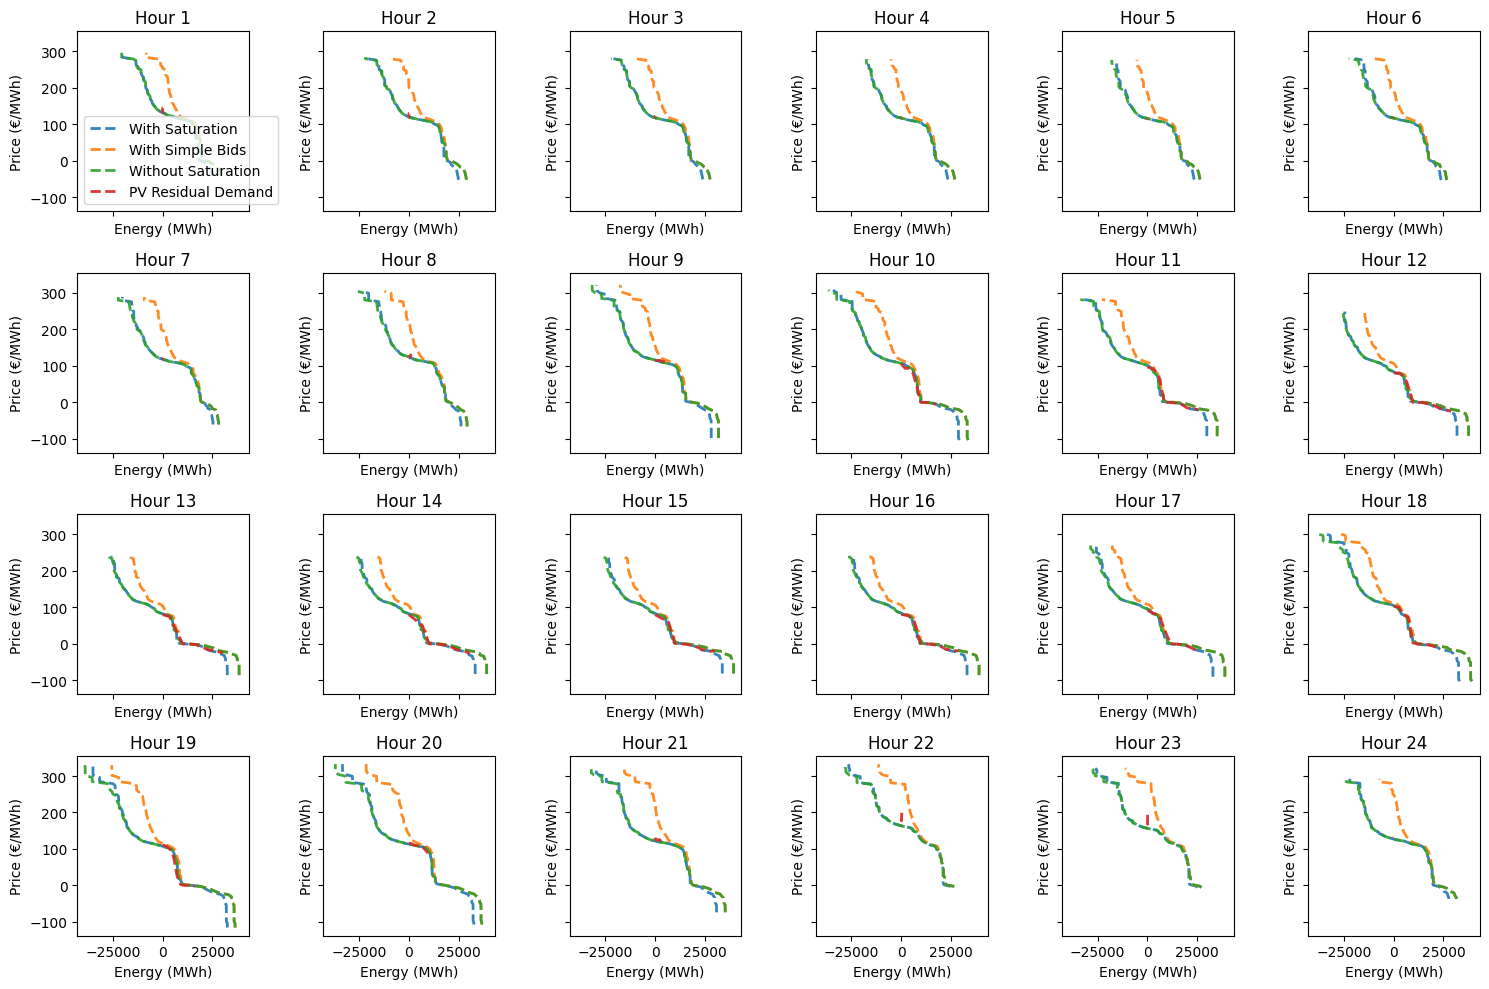

In [38]:
from mibel_simulator.plot_helpers import plot_residual_demand_curves

fig, axs = plt.subplots(4, 6, figsize=(15, 10), sharex=True, sharey=True)

plot_residual_demand_curves(
    residual_demand_curves_dict["residual_demands_with_saturation_curves"],
    axs=axs,
    label="With Saturation",
)
plot_residual_demand_curves(
    residual_demand_curves_dict["residual_demands_with_simple_bids_curves"],
    axs=axs,
    label="With Simple Bids",
)
plot_residual_demand_curves(
    residual_demand_curves_dict["residual_demands_without_saturation_curves"],
    axs=axs,
    label="Without Saturation",
)
plot_residual_demand_curves(
    PV_residual_demand_curve,
    axs=axs,
    label="PV Residual Demand",
)
plt.tight_layout()
plt.show()

In [50]:
from mibel_simulator.residual_demand_curve import interpolate_residual_demand_curves


interpolated_rdc_with_saturation = interpolate_residual_demand_curves(
    PV_residual_demand_curve,
    residual_demand_curves_dict["residual_demands_with_saturation_curves"],
)

interpolated_rdc_with_saturation

,energy_1,energy_2,energy_3,energy_4,energy_5,energy_6,energy_7,energy_8,energy_9,energy_10,...,price_15,price_16,price_17,price_18,price_19,price_20,price_21,price_22,price_23,price_24
scale_0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,83.418857,83.994434,95.609029,104.878095,107.398512,113.295268,121.830714,163.375455,156.411047,126.980039
scale_0.22,8.355547,8.259128,8.264039,8.249004,8.285576,8.503372,18.520281,143.925544,786.256903,1942.305815,...,77.489643,77.900989,82.262299,95.843148,104.347929,112.021575,121.326249,163.305452,156.397929,126.964284
scale_0.44,16.711094,16.518256,16.528079,16.498009,16.571151,17.006744,37.040562,287.851088,1572.513805,3884.611630,...,39.488773,48.532540,70.497538,79.743534,100.780312,110.747883,120.821784,163.235450,156.384812,126.948529
scale_0.67,25.066642,24.777385,24.792118,24.747013,24.856727,25.510115,55.560843,431.776632,2358.770708,5826.917445,...,3.025911,1.384795,17.898680,44.615947,92.187773,109.505966,120.317319,163.165448,156.371695,126.932774
scale_0.89,33.422189,33.036513,33.056158,32.996017,33.142303,34.013487,74.081124,575.702175,3145.027610,7769.223260,...,0.633675,-0.098976,0.055132,4.936082,58.539173,108.320722,119.887214,163.095445,156.358577,126.917020
scale_1.11,41.777736,41.295641,41.320197,41.245022,41.427878,42.516859,92.601406,719.627719,3931.284513,9711.529075,...,-2.265052,-1.582746,-1.449340,-0.765874,14.962105,107.135477,119.554486,163.025443,156.345460,126.901265
scale_1.33,50.133283,49.554769,49.584237,49.494026,49.713454,51.020231,111.121687,863.553263,4717.541416,11653.834890,...,-6.746924,-4.404400,-2.953812,-2.171551,2.321827,105.950233,119.221759,162.955441,156.332343,126.885510
scale_1.56,58.488830,57.813897,57.848276,57.743030,57.999029,59.523603,129.641968,1007.478807,5503.798318,13596.140704,...,-16.728352,-13.474890,-7.039815,-3.577227,1.154281,104.764988,118.889032,162.885438,156.319226,126.869755
scale_1.78,66.844378,66.073025,66.112316,65.992035,66.284605,68.026975,148.162249,1151.404351,6290.055221,15538.446519,...,-19.105632,-19.900411,-14.480554,-4.982904,-0.013265,101.894129,118.556304,162.815436,156.306108,126.854001
scale_2.00,75.199925,74.332154,74.376355,74.241039,74.570181,76.530346,166.682530,1295.329895,7076.312123,17480.752334,...,-27.161785,-23.894404,-18.900987,-9.214343,-1.180810,96.477444,118.223577,162.749059,156.292991,126.838246


In [52]:
from mibel_simulator.const import RDC_PRICE_COLUMNS


(
    PV_residual_demand_curve[RDC_PRICE_COLUMNS]
    - interpolated_rdc_with_saturation[RDC_PRICE_COLUMNS]
)

,price_1,price_2,price_3,price_4,price_5,price_6,price_7,price_8,price_9,price_10,...,price_15,price_16,price_17,price_18,price_19,price_20,price_21,price_22,price_23,price_24
scale_0.00,-2.149673,-2.201605,-1.548574,-1.304699,-1.235970,-1.203151,-2.074608,-2.860737,-1.300771,-1.814326,...,-3.228857,-3.594434,-3.609029,-2.228095,3.531488,3.334732,9.049286,19.294545,13.588953,2.799961
scale_0.22,-2.133591,-2.185010,-1.535241,-1.294415,-1.225838,-1.192681,-2.044254,-2.618373,-0.194388,-9.368162,...,-7.489643,0.259011,1.737701,5.156852,3.652071,2.778425,3.673751,13.704548,11.332071,2.815716
scale_0.44,1.282490,0.311585,-0.401907,-0.884132,-0.035706,-0.782212,-1.533900,1.203992,1.206215,-3.505600,...,21.211227,16.477460,8.512462,0.446466,-0.780312,0.822117,4.178216,13.774550,11.545188,2.831471
scale_0.67,7.838572,2.328180,1.331426,-0.623849,0.324427,-0.691742,-0.383546,2.236356,2.669530,-9.910111,...,-2.175911,-0.354795,19.271320,28.484053,-12.177773,0.494034,4.682681,19.404552,13.628305,2.847226
scale_0.89,7.454654,2.344776,1.344760,-0.613566,0.334559,-0.681272,-0.353192,2.068721,3.392845,-15.535777,...,-0.643675,0.088976,-0.055132,-2.536082,-31.939173,0.789278,5.112786,19.704555,23.641423,2.862980
scale_1.11,8.900736,4.561371,1.918093,-0.143282,0.444691,-0.290803,0.797162,4.161085,2.596832,-5.597670,...,0.265052,-0.417254,0.949340,0.765874,-12.552105,0.884523,5.445514,28.274557,26.424540,2.878735
scale_1.33,12.976817,9.707966,4.131427,0.737001,0.754823,0.839667,2.597517,7.803450,3.335489,0.224800,...,0.946924,-0.795600,0.853812,1.571551,-2.321827,1.089767,5.778241,29.564559,35.887657,3.114490
scale_1.56,12.992899,9.724561,4.144760,0.747284,0.734956,0.850136,2.627871,7.065814,2.524145,0.989125,...,1.728352,-1.525110,1.039815,1.577227,-1.154281,-2.624988,6.110968,37.114562,37.680774,4.010245
scale_1.78,13.008981,9.741156,4.158094,0.757568,0.745088,0.860606,2.658225,4.798179,2.412802,0.853450,...,-0.884368,2.900411,-0.519446,-0.017096,-0.486735,-6.894129,2.943696,37.184564,37.693892,4.025999
scale_2.00,13.025063,9.757752,4.171427,0.767851,0.755220,0.871075,2.688579,3.730082,2.301459,-1.682226,...,7.151785,3.894404,0.900987,-0.785657,-0.819190,-8.157444,2.486423,37.250941,37.707009,4.041754


In [ ]:
simple_rdcs = {}
complex_rdcs = {}
adjusted_rdcs = {}

for date in pd.date_range(start=START_ANALYSIS, end=END_ANALYSIS):
    print("date: ", date)
    date_plotted = date.strftime("%Y-%m-%d")
    simple_rdcs[date_plotted] = {i: {} for i in range(1, 25)}
    complex_rdcs[date_plotted] = {i: {} for i in range(1, 25)}
    adjusted_rdcs[date_plotted] = {i: {} for i in range(1, 25)}

    price_curves_date = get_price_curves(date_plotted)
    cleared_det_cab_dates = {i: {} for i in range(len(price_curves_date))}
    det_cab_date = get_det_cab_date(date_plotted)
    capacidad_inter_PT_date = get_capacidad_inter_PT_date(date_plotted)

    for idx, price_curve_date in enumerate(price_curves_date):

        price_curve_dict = {i: price_curve_date[i - 1] for i in range(1, 25)}
        det_cab_date_aux = det_cab_date.copy()
        det_cab_date_aux["cleared_price"] = det_cab_date_aux["Periodo"].map(
            price_curve_dict
        )
        det_cab_date_aux["cleared_energy"] = calculate_det_cab_date_cleared_energy(
            det_cab_date_aux
        )

        det_cab_date_exchanges_fr = det_cab_date_aux.query('CodigoUnidad == "MIEU"')
        # import (venta) negative - export (compra) positive
        det_cab_date_exchanges_fr.loc[:, "cleared_energy"] = np.where(
            det_cab_date_exchanges_fr["CV"] == "C",
            det_cab_date_exchanges_fr["cleared_energy"],
            -det_cab_date_exchanges_fr["cleared_energy"],
        )

        energy_hourly_cleared_C = (
            det_cab_date_aux.query('CV == "C"')
            .groupby("Periodo")["cleared_energy"]
            .sum()
            .sort_index()
        )
        energy_hourly_cleared_V_S = (
            det_cab_date_aux.query('CV == "V" & cod_simple_block_orders == "S"')
            .groupby("Periodo")["cleared_energy"]
            .sum()
            .sort_index()
        )
        energy_hourly_cleared_V = (
            det_cab_date_aux.query('CV == "V"')
            .groupby("Periodo")["cleared_energy"]
            .sum()
            .sort_index()
        )
        energy_hourly_cleared_exchanges_fr = (
            det_cab_date_exchanges_fr.groupby("Periodo")["cleared_energy"]
            .sum()
            .sort_index()
        )

        residual_demand_hourly_simple = energy_hourly_cleared_C.add(
            energy_hourly_cleared_exchanges_fr, fill_value=0
        ).sub(energy_hourly_cleared_V_S, fill_value=0)

        residual_demand_hourly = energy_hourly_cleared_C.sub(
            energy_hourly_cleared_V, fill_value=0
        )

        residual_demand_with_saturation_hourly = (
            calculate_residual_demand_with_saturation_hourly(
                det_cab_date_aux, capacidad_inter_PT_date
            )
        )

        for hour in range(1, 25):
            simple_rdcs[date_plotted][hour][price_curve_date[hour - 1]] = (
                residual_demand_hourly_simple[hour]
            )
            complex_rdcs[date_plotted][hour][price_curve_date[hour - 1]] = (
                residual_demand_hourly[hour]
            )
            adjusted_rdcs[date_plotted][hour][price_curve_date[hour - 1]] = (
                residual_demand_with_saturation_hourly[hour]
            )
        cleared_det_cab_dates[idx] = det_cab_date_aux

/tmp/ipykernel_761165/1711850340.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  spain_cleared_prices_date = marginalpdbc_raw.query(


date:  2025-07-01 00:00:00


NameError: name 'get_det_cab_date' is not defined

In [ ]:
rdc_dfs = {}

for date in pd.date_range(start=START_ANALYSIS, end=END_ANALYSIS):
    date_plotted = date.strftime("%Y-%m-%d")
    rdc_dfs[date_plotted] = {}
    for i in range(1, 25):
        rdc_dfs[date_plotted][i] = (
            pd.DataFrame(
                {
                    "Simple no exchanges": simple_rdcs[date_plotted][i],
                    "Complex": complex_rdcs[date_plotted][i],
                    "Split adjusted": adjusted_rdcs[date_plotted][i],
                }
            )
            .reset_index()
            .rename(columns={"index": "PrecEuro"})
        )

fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs_flat = axs.flatten()

for idx, ax in enumerate(axs_flat):
    hour = idx + 1
    for col in ["Simple no exchanges", "Complex", "Split adjusted"]:
        ax.plot(
            rdc_dfs[date_plotted][hour][col],
            rdc_dfs[date_plotted][hour]["PrecEuro"],
            label=col,
        )
        ax.set_title(f"RDCs - Hour {hour}")
        ax.set_xlabel("RDC (MWh)")
        ax.set_ylabel("Price (€/MWh)")
        ax.legend() if idx == 0 else None

In [ ]:
fig, axs = plt.subplots(4, 6, figsize=(22, 15), sharex=True, sharey=True)
axs_flat = axs.flatten()

rdc_types = ["PV", "Basic", "Hidro"]

filenames_dict = {"PV": "PV", "Basic": "basic", "Hidro": "hidro"}

hourly_errors = {rdc_type: {} for rdc_type in rdc_types}
hourly_errors_dfs = {rdc_type: {} for rdc_type in rdc_types}
interpolated_analytic_rdcs = {rdc_type: {} for rdc_type in rdc_types}

for rdc_type in rdc_types:
    for date in pd.date_range(start=START_ANALYSIS, end=END_ANALYSIS):
        DATE_STUDIED = date.strftime("%Y-%m-%d")
        residual_demand_curve = pd.read_parquet(
            f"results/residual_demand_curve_{filenames_dict[rdc_type]}_{DATE_STUDIED}.parquet"
        )
        hourly_errors[rdc_type][DATE_STUDIED] = {}
        hourly_errors_dfs[rdc_type][DATE_STUDIED] = {}
        interpolated_analytic_rdcs[rdc_type][DATE_STUDIED] = {}

        for i in range(1, 25):
            simulated_rdc = residual_demand_curve[[f"energy_{i}", f"price_{i}"]].copy()
            analytic_rdc = (
                rdc_dfs[DATE_STUDIED][i]
                .sort_values("Split adjusted")
                .reset_index(drop=True)
            )

            min_analytic_energy = analytic_rdc["Split adjusted"].min()
            max_analytic_energy = analytic_rdc["Split adjusted"].max()

            simulated_rdc_testeable = simulated_rdc.query(
                f"@min_analytic_energy <= energy_{i} <= @max_analytic_energy"
            )

            interpolated_analytic_prices = np.interp(
                simulated_rdc_testeable[f"energy_{i}"],
                analytic_rdc["Split adjusted"],
                analytic_rdc["PrecEuro"],
            )

            interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i] = pd.DataFrame(
                {
                    "Energia": simulated_rdc_testeable[f"energy_{i}"],
                    "Precio_analytic": interpolated_analytic_prices,
                    "Precio_simulated": simulated_rdc_testeable[f"price_{i}"],
                }
            )
            hourly_errors[rdc_type][DATE_STUDIED][i] = (
                (
                    interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i][
                        "Precio_simulated"
                    ]
                    - interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i][
                        "Precio_analytic"
                    ]
                )
                .abs()
                .mean()
            )
            hourly_errors_dfs[rdc_type][DATE_STUDIED][i] = pd.DataFrame(
                {
                    "Error": interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i][
                        "Precio_simulated"
                    ]
                    - interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i][
                        "Precio_analytic"
                    ],
                    "Energy": interpolated_analytic_rdcs[rdc_type][DATE_STUDIED][i][
                        "Energia"
                    ],
                    "Price_analytic": interpolated_analytic_rdcs[rdc_type][
                        DATE_STUDIED
                    ][i]["Precio_analytic"],
                    "Price_simulated": interpolated_analytic_rdcs[rdc_type][
                        DATE_STUDIED
                    ][i]["Precio_simulated"],
                }
            )

# for i in range(1, 25):
#     simulated_rdc = residual_demand_curve[[f"energy_{i}", f"price_{i}"]].copy()
#     analytic_rdc = rdc_dfs[i].sort_values("Split adjusted").reset_index(drop=True)

#     min_analytic_energy = analytic_rdc["Split adjusted"].min()
#     max_analytic_energy = analytic_rdc["Split adjusted"].max()

#     simulated_rdc_testeable = simulated_rdc.query(
#         f"@min_analytic_energy <= energy_{i} <= @max_analytic_energy"
#     )

#     interpolated_analytic_prices = np.interp(
#         simulated_rdc_testeable[f"energy_{i}"],
#         analytic_rdc["Split adjusted"],
#         analytic_rdc["PrecEuro"],
#     )

#     interpolated_analytic_rdcs[i] = pd.DataFrame(
#         {
#             "Energia": simulated_rdc_testeable[f"energy_{i}"],
#             "Precio_analytic": interpolated_analytic_prices,
#             "Precio_simulated": simulated_rdc_testeable[f"price_{i}"],
#         }
#     )
#     hourly_errors[i] = (
#         (
#             interpolated_analytic_rdcs[i]["Precio_simulated"]
#             - interpolated_analytic_rdcs[i]["Precio_analytic"]
#         )
#         .abs()
#         .mean()
#     )
#     hourly_errors_dfs[i] = pd.DataFrame(
#         {
#             "Error": interpolated_analytic_rdcs[i]["Precio_simulated"]
#             - interpolated_analytic_rdcs[i]["Precio_analytic"],
#             "Energy": interpolated_analytic_rdcs[i]["Energia"],
#             "Price_analytic": interpolated_analytic_rdcs[i]["Precio_analytic"],
#             "Price_simulated": interpolated_analytic_rdcs[i]["Precio_simulated"],
#         }
#     )


# display mae

# display(f"MAE: {np.mean(list(hourly_errors.values()))} €/MWh")

# hourly_errors_df = pd.DataFrame.from_dict(
#     hourly_errors, orient="index", columns=["MAE"]
# )
# hourly_errors_df.plot()
# plt.title("Mean Absolute Error of Simulated RDC vs Analytic RDC")
# plt.xlabel("Hour")
# plt.ylabel("Mean Absolute Error (€/MWh)")
# plt.show()

# Error entre RDCs

In [ ]:
errors_dfs = []
for rdc_type in rdc_types:
    errors_df = pd.DataFrame(hourly_errors[rdc_type])
    errors_df["rdc_type"] = rdc_type
    errors_dfs.append(errors_df)

errors_df_all = (
    pd.concat(errors_dfs)
    .reset_index()
    .rename(columns={"index": "Hour", 0: "MAE"})
    .melt(id_vars=["rdc_type", "Hour"], value_name="MAE", var_name="Date")
)
errors_df_all["datetime"] = pd.to_datetime(errors_df_all["Date"]) + pd.to_timedelta(
    errors_df_all["Hour"] - 1, unit="H"
)

fig, ax = plt.subplots(figsize=(12, 6))
for rdc_type, grp in errors_df_all.sort_values("datetime").groupby("rdc_type"):
    grp.plot(
        x="datetime",
        y="MAE",
        title="Mean Absolute Error of Simulated RDC vs Analytic RDC",
        label=rdc_type,
        xlabel="Date and Hour",
        ylabel="Mean Absolute Error (€/MWh)",
        legend=True,
        ax=ax,
    )